In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

/home/ssuarez/tutorials/pytorch_tutorial/.env/lib/python3.9/site-packages/torch/autograd/__init__.py:394: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11050). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  result = Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [0/40000], Loss: 345.66552734375
Epoch [1000/40000], Loss: 1.3584920167922974
Epoch [2000/40000], Loss: 1.3503162860870361
Epoch [3000/40000], Loss: 1.3436570167541504
Epoch [4000/40000], Loss: 1.3394502401351929
Epoch [5000/40000], Loss: 1.3380026817321777
Epoch [6000/40000], Loss: 1.3376691341400146
Epoch [7000/40000], Loss: 1.3373130559921265
Epoch [8000/40000], Loss: 1.3365693092346191
Epoch [9000/40000], Loss: 1.3350906372070312
Epoch [10000/40000], Loss: 1.3311583995819092
Epoch [11000/40000], Loss: 1.3223332166671753
Epoch [12000/40000], Loss: 1.292328119277954
Epoch [13000/40000], Loss: 1.0815891027450562
Epoch [14000/40000], Loss: 0.7930347919464111
Epoch [15000/40000], Loss: 0.556464433670044
Epoch [16000/40000], Loss: 0.41770899295806885
Epoch [17000/40000], Loss: 0.34416159987449646
Epoch [18000/40000], Loss: 0.2972528040409088
Epoch [19000/40000], Loss: 0.2597692310810089
Epoch [20000/40000], Loss: 0.22795173525810242
Epoch [21000/40000], Loss: 0.20258256793022156
Ep

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


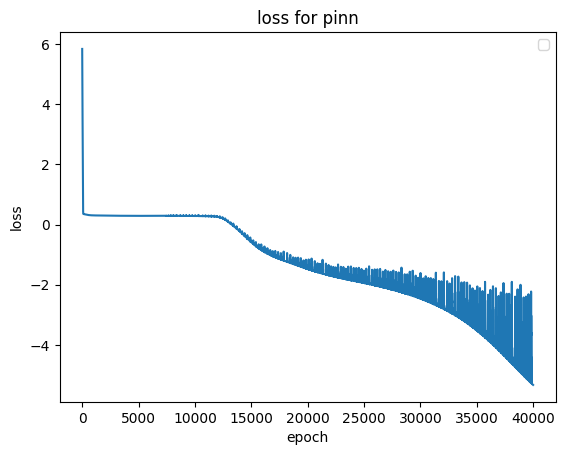

In [2]:


# parameters
ZETTA = 0.2
W = 10

# initial conditions
X0 = 1
X_T_0 = 0

# Define the PINN model
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),   # Input layer with 1 feature
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 1),    # Output layer for v(t)
        )

    def forward(self, t):
        return self.net(t)

# Define the Poisson equation loss function
def damped_oscillatior_loss(model, t):
    x = model(t)
    x_t = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True)[0]
    x_tt = torch.autograd.grad(x_t, t, grad_outputs=torch.ones_like(x_t), create_graph=True)[0]
    f = (x_tt + (2*ZETTA*W)*x_t + (W**2)*x)**2  # Poisson equation: u_xx = 1
    t_0 = torch.tensor([0.0], requires_grad=True)
    x_0 = model(t_0)
    initial_conditions = (x_0 - X0)**2
    x_t_0 = torch.autograd.grad(x_0, t_0, grad_outputs=torch.ones_like(x_0), create_graph=True)[0]
    initial_conditions_der = (x_t_0 - X_T_0)**2
    return torch.mean(f) + \
        torch.mean(initial_conditions) + \
        torch.mean(initial_conditions_der) + \
        (-0.0629 - model(torch.tensor([0.4848])))**2 + \
        (-0.5183 - model(torch.tensor([0.3030])))**2 + \
        (0.2595 - model(torch.tensor([0.6061])))**2

# Training data
t = 2*torch.rand(100, 1)  # Randomly sampled points in [0, 1]
t.requires_grad = True

# Create PINN model
model = PINN()

optimizer = optim.Adam(params=[{'params': model.parameters()}, {'params': t}], lr=1e-4)

# loss tracking
losses = []

# Training loop
epochs = 40000
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Compute the loss
    loss = damped_oscillatior_loss(model, t)
    
    # Backpropagation
    loss.backward()
    losses.append(torch.log(loss).item())
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item()}")


import matplotlib.pyplot as plt
plt.figure()
plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('loss for pinn')
plt.legend()
plt.show()

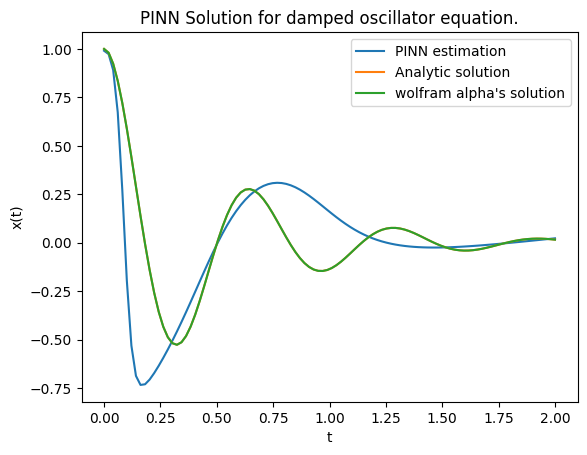

In [3]:
# Test the model
t_test = 2*torch.linspace(0, 1, 100).reshape(-1, 1)
x_test = model(t_test)
Z = ZETTA
w = W
root = torch.sqrt(torch.tensor([Z**2 - 1], dtype=torch.cfloat))
x_real = X0*torch.exp(-w*Z*t_test)*(torch.cosh(w*root*t_test) + (Z/root)*torch.sinh(w*root*t_test))
x_real = x_real.real

# wolfram alpha's solution:
six = torch.tensor([6.0])
x_sth = (1/12)*torch.exp(-2*t_test)*(torch.sqrt(six)*torch.sin(4*torch.sqrt(six)*t_test) + 12*torch.cos(4*torch.sqrt(six)*t_test))


# Plot the results
import matplotlib.pyplot as plt
plt.figure()
plt.plot(t_test.detach().numpy(), x_test.detach().numpy(), label="PINN estimation")
plt.plot(t_test.detach().numpy(), x_real.detach().numpy(), label="Analytic solution")
plt.plot(t_test.detach().numpy(), x_sth.detach().numpy(), label="wolfram alpha's solution")
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('PINN Solution for damped oscillator equation.')
plt.legend()
plt.show()

It appears that a certain net can only convert to a certain estimate solution to
the differential equation. Maybe it seems that the expresivity of the net is
too restricted by its architecture?

Different architectures tend to converge to different things, but none of those
is too good to get confused with the actual solution. I think that the
differential equation tends to give "local" information, so each little interval
around a point verifies the differential equation, but not necesarily the same
initial conditions.

I believe (for now) in that. The neural network solves "locally" the initial
condition problem, but for distant points, the initial condition does not work
that much anymore.

More points on the domain of the target function does not seem to improve the
performance of the PINN.

More data (measurements) on the domain of the target function seem to modify
immensly the solution to the given differential equation.
